<a href="https://colab.research.google.com/github/LIBY70/Data-Analysis/blob/main/ida_week13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab13: 머신러닝 II — 회귀와 앙상블

본 실습 자료는 『배워서 바로 써먹는 데이터 분석 with 파이썬』 (설진욱, 생능북스) 및
『파이썬을 활용한 빅데이터 분석개론』 (안기수, 생능출판사)의 내용을 참고하여 제작되었습니다.

## 0. 라이브러리 불러오기

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### 한글 폰트 설정

In [ ]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import platform

if platform.system() == 'Darwin':
    mpl.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    mpl.rc('font', family='Malgun Gothic')
else:
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    mpl.rc('font', family='NanumGothic')

mpl.rc('axes', unicode_minus=False)
print('폰트 설정 완료:', mpl.rcParams['font.family'])

폰트 설정 완료: ['NanumGothic']


---
## PART 1. 데이터 준비 — 캘리포니아 주택 가격 데이터

**데이터셋**: `sklearn.datasets.fetch_california_housing()`
- 표본: **20,640개** 블록 그룹
- 변수: **8개** 수치형 특성
- 목표: 주택 **중앙값** 예측 (단위: \$100,000)

| 특성 | 설명 |
|---|---|
| **MedInc** | 블록 그룹 중앙 소득 |
| **HouseAge** | 주택 중앙 연령 |
| **AveRooms** | 가구당 평균 방 수 |
| **AveBedrms** | 가구당 평균 침실 수 |
| **Population** | 블록 그룹 인구 |
| **AveOccup** | 가구당 평균 거주자 수 |
| **Latitude** | 위도 |
| **Longitude** | 경도 |

### 1-1. 데이터 로딩 및 탐색

In [ ]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # 주택 중앙값 (단위: $100,000)

print(f"데이터 크기: {df.shape}")
print(f"특성 수:    {len(housing.feature_names)}개")
print(f"특성 목록:  {list(housing.feature_names)}")
print(f"목표변수:   MedHouseVal (주택 중앙 가격, 단위: $100,000)")
df.head()

데이터 크기: (20640, 9)
특성 수:    8개
특성 목록:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
목표변수:   MedHouseVal (주택 중앙 가격, 단위: $100,000)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


### 1-2. 특성 분포 및 상관관계 시각화

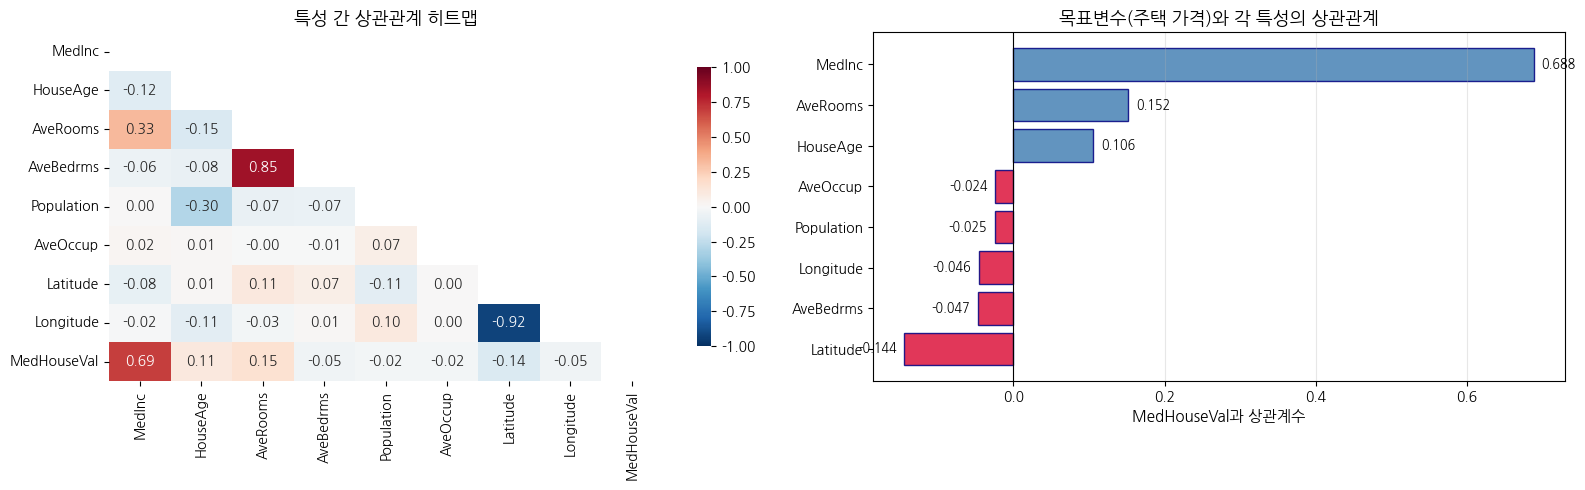

MedInc(소득)가 주택 가격과 상관관계가 가장 높음 → 중요한 예측 변수


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 상관관계 히트맵
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('특성 간 상관관계 히트맵', fontsize=13)

# 목표변수와 상관관계 막대그래프
target_corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors_bar = ['crimson' if v < 0 else 'steelblue' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, alpha=0.85, edgecolor='navy')
for i, (feat, val) in enumerate(target_corr.items()):
    offset = 0.01 if val >= 0 else -0.01
    axes[1].text(val + offset, i, f'{val:.3f}',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=9)
axes[1].set_xlabel('MedHouseVal과 상관계수', fontsize=11)
axes[1].set_title('목표변수(주택 가격)와 각 특성의 상관관계', fontsize=13)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print("MedInc(소득)가 주택 가격과 상관관계가 가장 높음 → 중요한 예측 변수")

### 1-3. 훈련/테스트 분할 및 표준화

Ridge / Lasso / ElasticNet은 **계수 크기에 페널티**를 부과하므로,  
변수 단위가 다르면 규제 효과가 왜곡된다 → **표준화(StandardScaler) 필수**.

> **주의**: `scaler.fit()`은 반드시 훈련셋에만 적용.  
> 테스트셋에 `fit_transform()`을 쓰면 테스트 정보가 훈련에 스며드는 **데이터 누수(Data Leakage)** 발생.

In [ ]:
X = housing.data
y = housing.target

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# 표준화 (평균=0, 표준편차=1)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)  # 훈련셋 기준 fit + transform
X_te_sc  = scaler.transform(X_te)      # 테스트셋은 transform만

print(f"전체 샘플: {len(X):,}개")
print(f"훈련셋:   {X_tr.shape[0]:,}개")
print(f"테스트셋: {X_te.shape[0]:,}개")
print()

before = pd.Series(X_tr.mean(axis=0),    index=housing.feature_names)
after  = pd.Series(X_tr_sc.mean(axis=0), index=housing.feature_names)
check_df = pd.DataFrame({'표준화 전 평균': before.round(3), '표준화 후 평균': after.round(6)})
print("표준화 전후 평균 비교 (표준화 후 ≈ 0)")
print(check_df)

전체 샘플: 20,640개
훈련셋:   16,512개
테스트셋: 4,128개

표준화 전후 평균 비교 (표준화 후 ≈ 0)
            표준화 전 평균  표준화 후 평균
MedInc         3.881      -0.0
HouseAge      28.608      -0.0
AveRooms       5.435       0.0
AveBedrms      1.097      -0.0
Population  1426.453      -0.0
AveOccup       3.097      -0.0
Latitude      35.643       0.0
Longitude   -119.582      -0.0


### 회귀 평가 함수 정의

- **MSE**: $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ — 이상치 민감
- **RMSE**: $\sqrt{\text{MSE}}$ — 원래 단위, 해석 용이
- **MAE**: $\frac{1}{n}\sum|y_i - \hat{y}_i|$ — 이상치 강건
- **R²**: $1 - SSR/SST$ — 설명력 (0 ~ 1)

In [ ]:
results = []  # 전체 모델 결과 저장

def eval_reg(y_true, y_pred, name):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"[{name}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {'모델': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R²': round(r2, 4)}

---
## PART 2. 선형 회귀와 규제 (Ridge / Lasso / ElasticNet)

선형회귀를 ML 관점으로 재해석하면 **비용함수(Loss Function) 최소화** 문제:

$$\min_{\mathbf{w}} \frac{1}{n}\sum_{i=1}^{n}(y_i - \mathbf{w}^\top \mathbf{x}_i)^2$$

변수가 많거나 다중공선성이 있을 때 과적합 위험 → **규제(Regularization)** 필요

- **Ridge (L2)**: $+\alpha\sum w_j^2$ — 계수를 0 근처로 수축, 변수 탈락 없음
- **Lasso (L1)**: $+\frac{\alpha}{2}\sum|w_j|$ — 일부 계수를 정확히 0 → 자동 변수 선택
- **ElasticNet**: $+\alpha\bigl[\rho\sum|w_j| + \frac{1-\rho}{2}\sum w_j^2\bigr]$ — L1+L2 결합

### 2-1. 기본 선형회귀 (OLS 베이스라인)

규제 없는 일반 선형회귀 — 이후 모델과 비교하는 기준점(Baseline)

In [ ]:
lr = LinearRegression()
lr.fit(X_tr_sc, y_tr)
y_pred_lr = lr.predict(X_te_sc)

results.append(eval_reg(y_te, y_pred_lr, '선형회귀(OLS)'))

print()
print("OLS 계수:")
coef_lr = pd.Series(lr.coef_, index=housing.feature_names)
print(coef_lr.round(4))
print(f"절편(intercept): {lr.intercept_:.4f}")

[선형회귀(OLS)]  RMSE=0.7456  MAE=0.5332  R²=0.5758

OLS 계수:
MedInc        0.8544
HouseAge      0.1225
AveRooms     -0.2944
AveBedrms     0.3393
Population   -0.0023
AveOccup     -0.0408
Latitude     -0.8969
Longitude    -0.8698
dtype: float64
절편(intercept): 2.0719


### 2-2. Ridge 회귀 (L2 규제)

$$J(\mathbf{w}) = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 + \frac{\alpha}{2}\sum_{j=1}^{p}w_j^2$$

- **α 클수록** 계수가 더 강하게 수축 (0에 가까워짐)
- 계수를 0 **근처로** 수축하지만 정확히 0은 아님 → 상관 변수가 많을 때 유리
- 스케일 정규화 필수

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_sc, y_tr)
y_pred_ridge = ridge.predict(X_te_sc)

results.append(eval_reg(y_te, y_pred_ridge, 'Ridge (α=1.0)'))

print()
print("Ridge 계수:")
coef_ridge = pd.Series(ridge.coef_, index=housing.feature_names)
compare_coef = pd.DataFrame({'OLS': coef_lr, 'Ridge': coef_ridge}).round(4)
print(compare_coef)
print()
print("→ L2 규제: 계수가 0에 가까워지지만 정확히 0이 되지는 않음")
print("→ 다중공선성 완화 효과: AveRooms/AveBedrms처럼 상관된 변수를 고르게 분배")

[Ridge (α=1.0)]  RMSE=0.7456  MAE=0.5332  R²=0.5758

Ridge 계수:
               OLS   Ridge
MedInc      0.8544  0.8543
HouseAge    0.1225  0.1226
AveRooms   -0.2944 -0.2942
AveBedrms   0.3393  0.3390
Population -0.0023 -0.0023
AveOccup   -0.0408 -0.0408
Latitude   -0.8969 -0.8962
Longitude  -0.8698 -0.8691

→ L2 규제: 계수가 0에 가까워지지만 정확히 0이 되지는 않음
→ 다중공선성 완화 효과: AveRooms/AveBedrms처럼 상관된 변수를 고르게 분배


### 2-3. Lasso 회귀 (L1 규제) — 자동 변수 선택

$$J(\mathbf{w}) = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 + \alpha\sum_{j=1}^{p}|w_j|$$

L1 페널티는 일부 계수를 **정확히 0**으로 만드는 **희소(Sparse) 해** 생성  
→ 자동으로 중요하지 않은 변수를 제거하는 **변수 선택** 효과

In [ ]:
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_tr_sc, y_tr)
y_pred_lasso = lasso.predict(X_te_sc)

results.append(eval_reg(y_te, y_pred_lasso, 'Lasso (α=0.1)'))

coef_lasso = pd.Series(lasso.coef_, index=housing.feature_names)
n_zero = (coef_lasso == 0).sum()
print(f"Lasso 계수 (0으로 설정된 특성 수: {n_zero}/{len(coef_lasso)}):")
print(coef_lasso.round(4))

zero_feats    = coef_lasso[coef_lasso == 0].index.tolist()
nonzero_feats = coef_lasso[coef_lasso != 0].index.tolist()
if zero_feats:
    print(f"자동 제거된 특성: {zero_feats}")
    print(f"선택된 특성:      {nonzero_feats}")
print("→ L1 규제: 일부 계수를 정확히 0으로 만들어 자동 변수 선택")

[Lasso (α=0.1)]  RMSE=0.8244  MAE=0.6222  R²=0.4814
Lasso 계수 (0으로 설정된 특성 수: 5/8):
MedInc        0.7106
HouseAge      0.1065
AveRooms     -0.0000
AveBedrms     0.0000
Population   -0.0000
AveOccup     -0.0000
Latitude     -0.0115
Longitude    -0.0000
dtype: float64
자동 제거된 특성: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
선택된 특성:      ['MedInc', 'HouseAge', 'Latitude']
→ L1 규제: 일부 계수를 정확히 0으로 만들어 자동 변수 선택


### 2-4. ElasticNet (L1 + L2 결합)

$$J(\mathbf{w}) = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 + \alpha\left[\rho\sum_j|w_j| + \frac{1-\rho}{2}\sum_j w_j^2\right]$$

- **α**: 전체 규제 강도
- **ρ (l1_ratio)**: L1 비율 (0이면 Ridge, 1이면 Lasso, 기본값 0.5)
- 상관 변수가 많으면서 일부 선택도 필요할 때 적합

In [ ]:
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
enet.fit(X_tr_sc, y_tr)
y_pred_enet = enet.predict(X_te_sc)

results.append(eval_reg(y_te, y_pred_enet, 'ElasticNet (α=0.1, ρ=0.5)'))

coef_enet  = pd.Series(enet.coef_, index=housing.feature_names)
n_zero_en  = (coef_enet == 0).sum()
print(f"ElasticNet 계수 (0으로 설정된 특성 수: {n_zero_en}/{len(coef_enet)}):")
print(coef_enet.round(4))
print("→ L1+L2 결합: Ridge의 안정성 + Lasso의 변수 선택")

[ElasticNet (α=0.1, ρ=0.5)]  RMSE=0.7974  MAE=0.5970  R²=0.5148
ElasticNet 계수 (0으로 설정된 특성 수: 4/8):
MedInc        0.7138
HouseAge      0.1373
AveRooms     -0.0000
AveBedrms     0.0000
Population    0.0000
AveOccup     -0.0000
Latitude     -0.1757
Longitude    -0.1333
dtype: float64
→ L1+L2 결합: Ridge의 안정성 + Lasso의 변수 선택


### 2-5. 규제 경로 — α에 따른 계수 변화

α를 변화시키면서 각 특성의 계수가 어떻게 바뀌는지 확인  
- **Ridge**: α 증가 → 계수가 서서히 0에 수렴 (절단 없음)
- **Lasso**: α 증가 → 계수가 갑자기 0으로 절단됨 (변수 탈락)

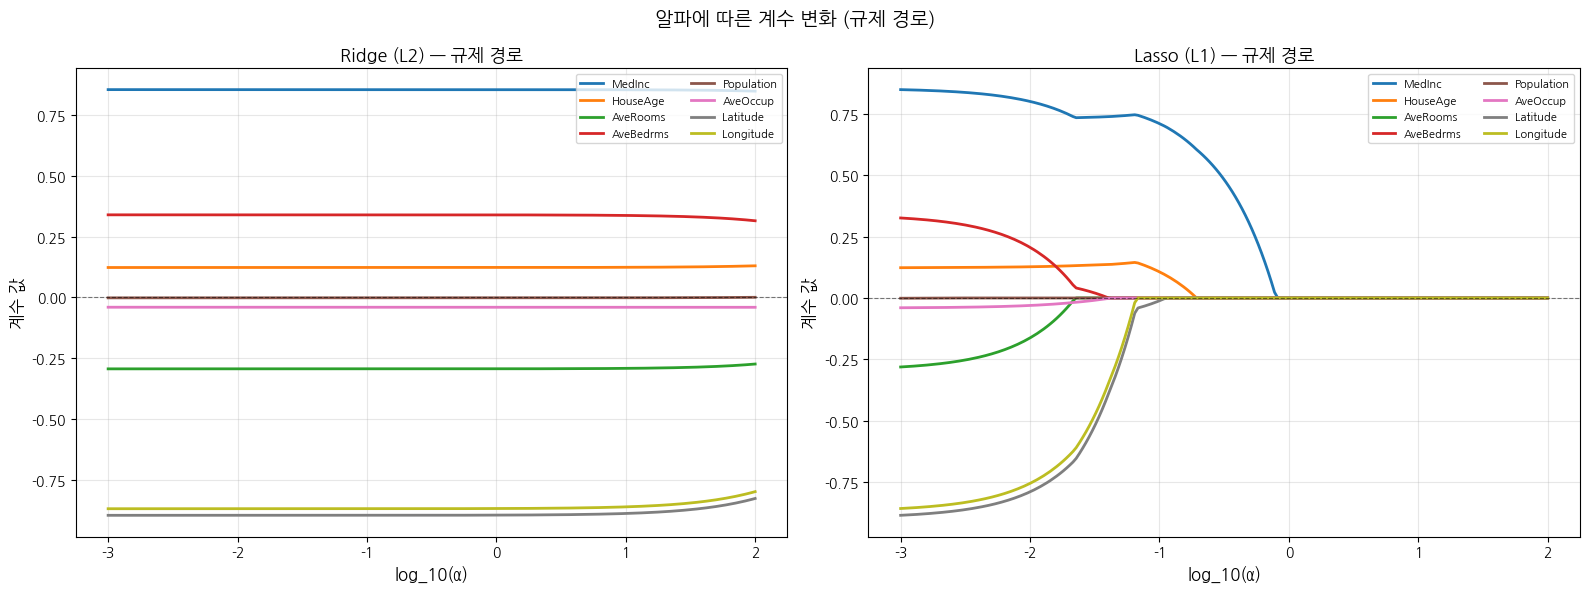

Ridge: α 증가 → 계수가 서서히 0에 수렴 (정확히 0이 안됨)
Lasso: α 증가 → 계수가 임계점에서 갑자기 0으로 절단됨 (변수 선택)


In [ ]:
alphas_path = np.logspace(-3, 2, 200)

ridge_path = np.array([Ridge(alpha=a).fit(X_tr_sc, y_tr).coef_ for a in alphas_path])
lasso_path = np.array([Lasso(alpha=a, max_iter=10000).fit(X_tr_sc, y_tr).coef_
                       for a in alphas_path])

cmap = plt.cm.tab10
feat_colors = [cmap(i / len(housing.feature_names)) for i in range(len(housing.feature_names))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, path, title in zip(
    axes,
    [ridge_path, lasso_path],
    ['Ridge (L2) — 규제 경로', 'Lasso (L1) — 규제 경로']
):
    for i, (feat, color) in enumerate(zip(housing.feature_names, feat_colors)):
        ax.plot(np.log10(alphas_path), path[:, i], color=color,
                linewidth=2, label=feat)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('log_10(α)', fontsize=12)
    ax.set_ylabel('계수 값', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('알파에 따른 계수 변화 (규제 경로)', fontsize=14)
plt.tight_layout()
plt.show()
print("Ridge: α 증가 → 계수가 서서히 0에 수렴 (정확히 0이 안됨)")
print("Lasso: α 증가 → 계수가 임계점에서 갑자기 0으로 절단됨 (변수 선택)")

### 2-6. 선형 모델 계수 비교 및 성능 정리

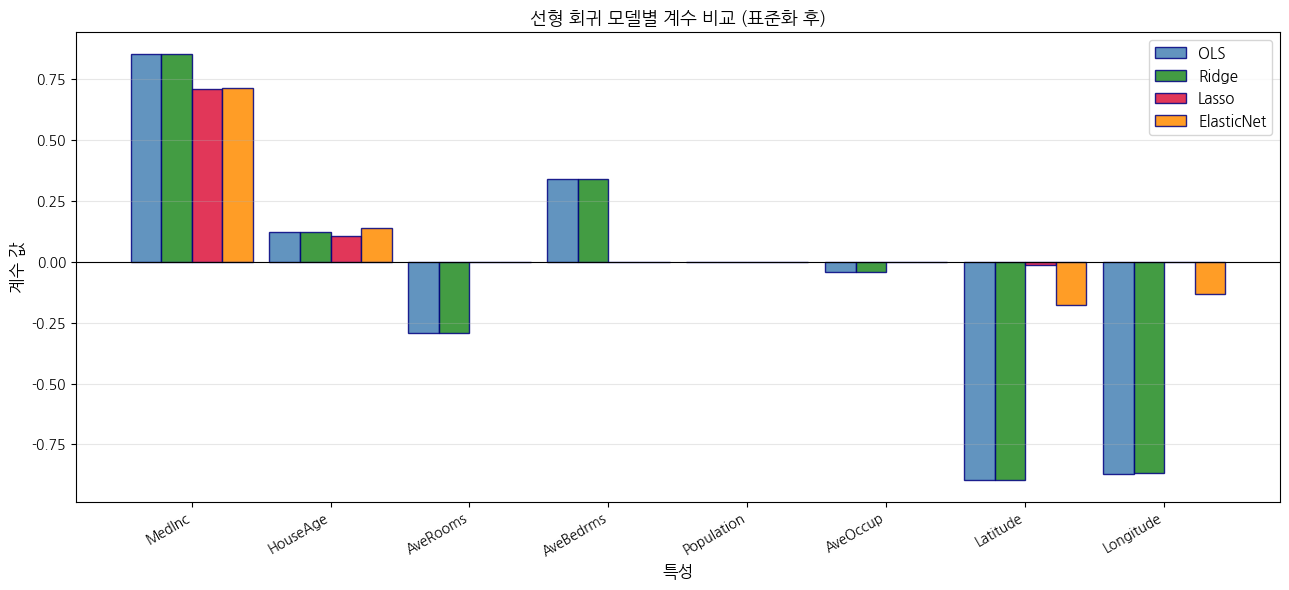

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

feats  = list(housing.feature_names)
x      = np.arange(len(feats))
width  = 0.22

model_info = [
    ('OLS',        lr.coef_,    'steelblue'),
    ('Ridge',      ridge.coef_, 'forestgreen'),
    ('Lasso',      lasso.coef_, 'crimson'),
    ('ElasticNet', enet.coef_,  'darkorange'),
]

for i, (name, coefs, color) in enumerate(model_info):
    offset = (i - 1.5) * width
    ax.bar(x + offset, coefs, width, label=name, color=color, alpha=0.85, edgecolor='navy')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feats, rotation=30, ha='right', fontsize=10)
ax.set_xlabel('특성', fontsize=12)
ax.set_ylabel('계수 값', fontsize=12)
ax.set_title('선형 회귀 모델별 계수 비교 (표준화 후)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## PART 3. RandomForest 회귀

분류와 동일한 배깅 앙상블 — 출력이 **클래스 대신 연속값(평균)**

| | Ridge/Lasso | RF 회귀 |
|---|---|---|
| 관계 가정 | 선형 | 비선형 가능 |
| 해석 가능성 | 높음 (계수 해석) | 낮음 |
| 변수 선택 | Lasso 가능 | 중요도 제공 |
| 다중공선성 | 취약 (OLS) / 강건 (Ridge) | 강건 |
| 스케일 정규화 | 필수 | 불필요 |

### 3-1. RandomForest 회귀 기본 모델

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr, y_tr)   # 스케일 정규화 불필요 — 원본 데이터 사용
y_pred_rf = rf_reg.predict(X_te)

results.append(eval_reg(y_te, y_pred_rf, 'RF 회귀 (n=100)'))

print()
print(f"훈련 R²: {r2_score(y_tr, rf_reg.predict(X_tr)):.4f}")
print(f"테스트 R²: {r2_score(y_te, y_pred_rf):.4f}")
print()
print("→ RF는 거리가 아닌 분기 기준 → 스케일 정규화 불필요")
print("→ 비선형 관계, 변수 간 교호작용 자동 포착")

[RF 회귀 (n=100)]  RMSE=0.5053  MAE=0.3275  R²=0.8051

훈련 R²: 0.9736
테스트 R²: 0.8051

→ RF는 거리가 아닌 분기 기준 → 스케일 정규화 불필요
→ 비선형 관계, 변수 간 교호작용 자동 포착


### 3-2. 특성 중요도 (Feature Importance)

각 변수가 전체 불순도 감소에 기여한 비율 — 합 = 1.0  
선형 모델의 계수와 달리 **방향(+/−)은 알 수 없고** 크기(중요도)만 제공

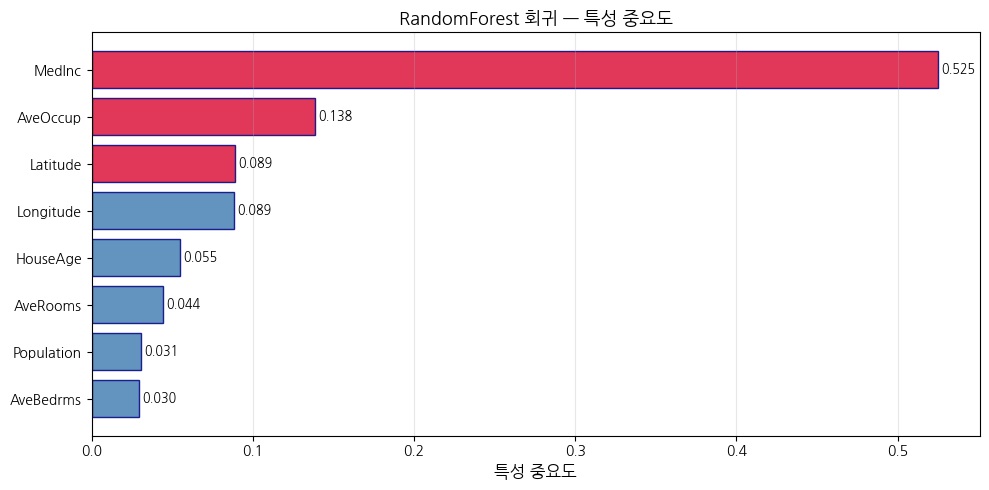

상위 3개 특성 (빨간색): ['Latitude', 'AveOccup', 'MedInc']
→ 전체 중요도의 75.2% 차지
→ MedInc(소득), Latitude/Longitude(위치)가 주택 가격의 핵심 변수


In [ ]:
fi = pd.Series(rf_reg.feature_importances_, index=housing.feature_names)
fi_sorted = fi.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['crimson' if i >= len(fi_sorted) - 3 else 'steelblue'
              for i in range(len(fi_sorted))]
bars = ax.barh(fi_sorted.index, fi_sorted.values,
               color=bar_colors, edgecolor='navy', alpha=0.85)
for bar, val in zip(bars, fi_sorted.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('특성 중요도', fontsize=12)
ax.set_title('RandomForest 회귀 — 특성 중요도', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

top3 = fi_sorted.tail(3).index.tolist()
print(f"상위 3개 특성 (빨간색): {top3}")
print(f"→ 전체 중요도의 {fi_sorted.tail(3).sum():.1%} 차지")
print("→ MedInc(소득), Latitude/Longitude(위치)가 주택 가격의 핵심 변수")

### 3-3. 전체 모델 성능 비교

In [ ]:
results_df = pd.DataFrame(results).set_index('모델')
print("전체 회귀 모델 성능 비교 (테스트셋)")
results_df.sort_values('R²', ascending=False)

전체 회귀 모델 성능 비교 (테스트셋)


,RMSE,MAE,R²
모델,,,
RF 회귀 (n=100),0.5053,0.3275,0.8051
선형회귀(OLS),0.7456,0.5332,0.5758
Ridge (α=1.0),0.7456,0.5332,0.5758
"ElasticNet (α=0.1, ρ=0.5)",0.7974,0.5970,0.5148
Lasso (α=0.1),0.8244,0.6222,0.4814


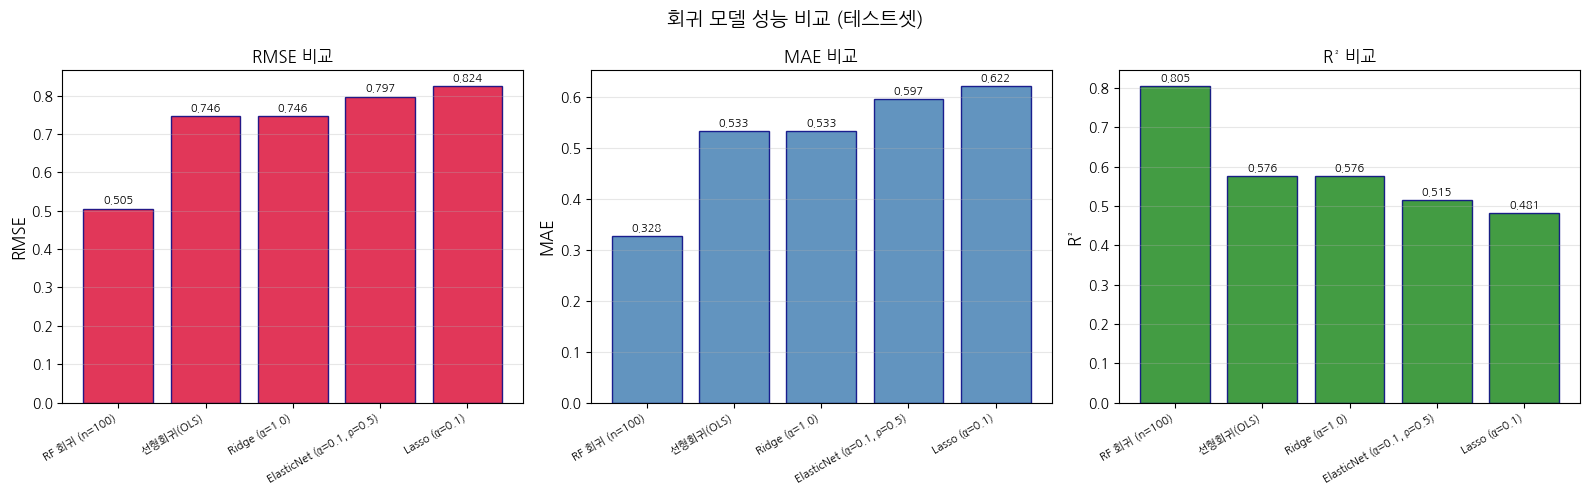

RF 회귀가 비선형 관계 포착으로 가장 높은 R² 달성
선형 모델 중에는 OLS가 이 데이터에서 Ridge/Lasso와 비슷한 성능
→ 선형 관계가 강하고 다중공선성이 낮을 때 규제 효과가 크지 않을 수 있음


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_palette = {'RMSE': 'crimson', 'MAE': 'steelblue', 'R²': 'forestgreen'}

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    ascending = (metric != 'R²')  # R²는 클수록 좋음
    vals = results_df[metric].sort_values(ascending=ascending)
    bars = ax.bar(range(len(vals)), vals.values,
                  color=metric_palette[metric], alpha=0.85, edgecolor='navy')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals.values) * 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} 비교', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('회귀 모델 성능 비교 (테스트셋)', fontsize=14)
plt.tight_layout()
plt.show()
print("RF 회귀가 비선형 관계 포착으로 가장 높은 R² 달성")
print("선형 모델 중에는 OLS가 이 데이터에서 Ridge/Lasso와 비슷한 성능")
print("→ 선형 관계가 강하고 다중공선성이 낮을 때 규제 효과가 크지 않을 수 있음")

---
## PART 4. 교차검증과 모델 선택

### K-Fold 교차검증 원리

데이터를 K등분하여 매 반복마다 다른 Fold를 검증셋으로 사용 → **안정적인 성능 추정**

- 전체 데이터를 K개 Fold로 분할
- K번 반복: 각 반복마다 1개 Fold = 검증, 나머지 = 훈련  
- 최종 성능 = K개 검증 점수의 **평균**
- 일반적으로 **K = 5 또는 10** 사용

### 4-1. K-Fold 교차검증 (`cross_val_score`)

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    '선형회귀(OLS)': LinearRegression(),
    'Ridge (α=1)':   Ridge(alpha=1.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1, max_iter=10000),
    'ElasticNet':    ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}

print("5-Fold 교차검증 결과 (R² 기준)")
print(f"{'모델':<22}  {'CV 평균':>8}  {'표준편차':>8}  {'95% CI':>22}")
print('-' * 68)

cv_results_dict = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_tr_sc, y_tr, cv=kf, scoring='r2')
    cv_results_dict[name] = scores
    ci_low  = scores.mean() - 1.96 * scores.std()
    ci_high = scores.mean() + 1.96 * scores.std()
    print(f"{name:<22}  {scores.mean():>8.4f}  {scores.std():>8.4f}  "
          f"[{ci_low:.4f}, {ci_high:.4f}]")

print()
print("→ CV를 통해 테스트셋 없이 하이퍼파라미터 비교 가능")
print("→ 표준편차가 낮을수록 안정적인 모델")

5-Fold 교차검증 결과 (R² 기준)
모델                         CV 평균      표준편차                  95% CI
--------------------------------------------------------------------
선형회귀(OLS)                 0.6115    0.0124  [0.5872, 0.6357]
Ridge (α=1)               0.6115    0.0124  [0.5872, 0.6357]
Lasso (α=0.1)             0.4973    0.0110  [0.4757, 0.5189]
ElasticNet                0.5306    0.0114  [0.5083, 0.5529]

→ CV를 통해 테스트셋 없이 하이퍼파라미터 비교 가능
→ 표준편차가 낮을수록 안정적인 모델


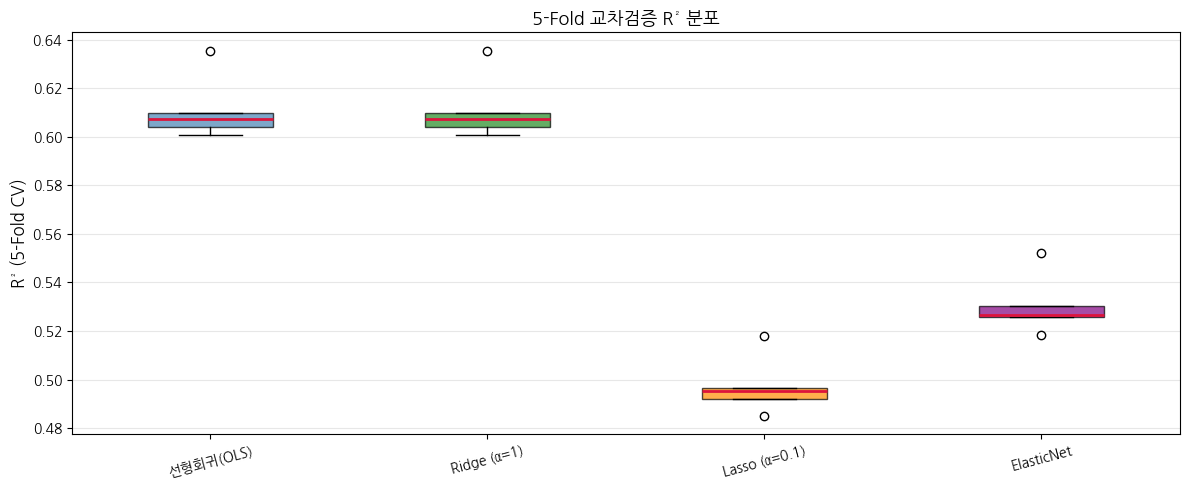

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

box_data   = [cv_results_dict[name] for name in cv_models.keys()]
box_labels = list(cv_models.keys())
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                medianprops=dict(color='crimson', linewidth=2))

box_colors = ['steelblue', 'forestgreen', 'darkorange', 'purple']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('R² (5-Fold CV)', fontsize=12)
ax.set_title('5-Fold 교차검증 R² 분포', fontsize=13)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4-2. GridSearchCV — 하이퍼파라미터 튜닝

모든 하이퍼파라미터 조합을 교차검증으로 평가하여 **최적 조합 자동 탐색**

1. 탐색 범위(`param_grid`) 지정
2. 모든 조합 × K-Fold 반복 실행
3. 평균 검증 점수가 가장 높은 조합 선택
4. `best_params_`로 최적 파라미터 반환

In [ ]:
param_grid = {
    'alpha':    [0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.2, 0.5, 0.8],
}

gs_enet = GridSearchCV(
    ElasticNet(max_iter=10000), param_grid, cv=5, scoring='r2'
)
gs_enet.fit(X_tr_sc, y_tr)

n_combos = len(param_grid['alpha']) * len(param_grid['l1_ratio'])
print(f"ElasticNet GridSearchCV 결과")
print(f"  탐색 조합 수: {n_combos}가지 × 5-Fold = {n_combos * 5}번 학습")
print(f"  최적 파라미터: {gs_enet.best_params_}")
print(f"  최적 CV R²:   {gs_enet.best_score_:.4f}")
print(f"  테스트 R²:    {gs_enet.best_estimator_.score(X_te_sc, y_te):.4f}")

ElasticNet GridSearchCV 결과
  탐색 조합 수: 12가지 × 5-Fold = 60번 학습
  최적 파라미터: {'alpha': 0.01, 'l1_ratio': 0.2}
  최적 CV R²:   0.6098
  테스트 R²:    0.5792


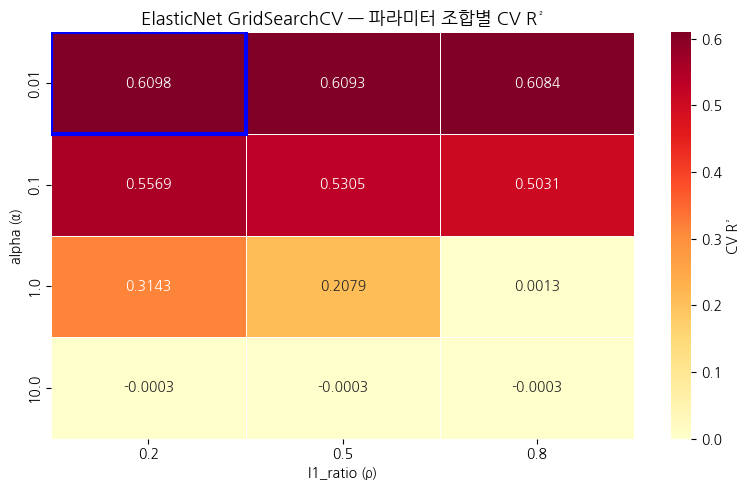

최적: α=0.01, ρ=0.2  →  파란 테두리 위치


In [ ]:
# CV 결과를 alpha × l1_ratio 피벗 테이블로 정리
res_df = pd.DataFrame(gs_enet.cv_results_)
pivot = res_df.pivot_table(
    index='param_alpha', columns='param_l1_ratio',
    values='mean_test_score'
)
pivot.index.name   = 'alpha (α)'
pivot.columns.name = 'l1_ratio (ρ)'

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'CV R²'}, linewidths=0.5)
ax.set_title('ElasticNet GridSearchCV — 파라미터 조합별 CV R²', fontsize=13)

# 최적 조합 위치 강조
alpha_sorted = sorted(param_grid['alpha'])
l1_sorted    = sorted(param_grid['l1_ratio'])
best_row = alpha_sorted.index(gs_enet.best_params_['alpha'])
best_col = l1_sorted.index(gs_enet.best_params_['l1_ratio'])
ax.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
                             fill=False, edgecolor='blue', lw=3))

plt.tight_layout()
plt.show()
print(f"최적: α={gs_enet.best_params_['alpha']}, ρ={gs_enet.best_params_['l1_ratio']}"
      f"  →  파란 테두리 위치")

### 4-3. sklearn Pipeline — 전처리 + 모델 통합

전처리와 모델을 **하나의 객체**로 묶어 데이터 누수 방지 및 코드 재사용성 향상

**Pipeline이 필요한 이유**  
- **데이터 누수(Data Leakage)**: 교차검증 시 전처리를 먼저 하면 검증셋 정보가 훈련에 포함  
- Pipeline은 각 Fold마다 **훈련셋만**으로 스케일러를 fit → 누수 방지

흔한 실수: `scaler.fit(X)` — 전체 데이터로 fit → 테스트 정보가 훈련에 스며듦

In [ ]:
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge())
])

# 파이프라인 파라미터: '스텝명__파라미터명'
pipe_param_grid = {'ridge__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

gs_pipe = GridSearchCV(pipe_ridge, pipe_param_grid, cv=5, scoring='r2')
gs_pipe.fit(X_tr, y_tr)   # 원본 데이터 사용 — 파이프라인이 내부에서 스케일링

print("Pipeline + GridSearchCV 결과")
print(f"  최적 α:      {gs_pipe.best_params_['ridge__alpha']}")
print(f"  최적 CV R²:  {gs_pipe.best_score_:.4f}")
print(f"  테스트 R²:   {gs_pipe.score(X_te, y_te):.4f}")
print()
print("Pipeline 장점:")
print("  1. 데이터 누수 방지: 각 Fold마다 훈련셋만으로 스케일러 fit")
print("  2. 코드 간결성:      전처리+모델을 하나의 객체로 관리")
print("  3. 배포 용이성:      predict() 한 번으로 전처리+예측 일괄 처리")

Pipeline + GridSearchCV 결과
  최적 α:      0.001
  최적 CV R²:  0.6115
  테스트 R²:   0.5758

Pipeline 장점:
  1. 데이터 누수 방지: 각 Fold마다 훈련셋만으로 스케일러 fit
  2. 코드 간결성:      전처리+모델을 하나의 객체로 관리
  3. 배포 용이성:      predict() 한 번으로 전처리+예측 일괄 처리


In [ ]:
# 파이프라인은 원본 데이터를 입력받아 내부에서 전처리 후 예측
sample = X_te[:5]
pred_pipe = gs_pipe.predict(sample)

# 파이프라인 내부 동작을 수동으로 재현
scaler_step = gs_pipe.best_estimator_.named_steps['scaler']
ridge_step  = gs_pipe.best_estimator_.named_steps['ridge']
pred_manual = ridge_step.predict(scaler_step.transform(sample))

print("파이프라인 예측 vs 수동 전처리+예측 (동일해야 함)")
for p1, p2 in zip(pred_pipe, pred_manual):
    print(f"  Pipeline: {p1:.4f}  |  Manual: {p2:.4f}  |  동일: {abs(p1 - p2) < 1e-10}")

파이프라인 예측 vs 수동 전처리+예측 (동일해야 함)
  Pipeline: 0.7191  |  Manual: 0.7191  |  동일: True
  Pipeline: 1.7640  |  Manual: 1.7640  |  동일: True
  Pipeline: 2.7097  |  Manual: 2.7097  |  동일: True
  Pipeline: 2.8389  |  Manual: 2.8389  |  동일: True
  Pipeline: 2.6047  |  Manual: 2.6047  |  동일: True


---
## PART 5. 분류·회귀 종합 비교

지금까지 배운 지도학습 알고리즘을 한자리에서 비교한다.

### 5-1. 분류 알고리즘 특성 비교

| | KNN | 의사결정나무 | 랜덤 포레스트 | 로지스틱 회귀 |
|---|---|---|---|---|
| **학습 방식** | Lazy | 분기 | 배깅 앙상블 | 선형 최적화 |
| **스케일 정규화** | 필요 | 불필요 | 불필요 | 권장 |
| **과적합 위험** | K에 따라 | 높음 | 낮음 | 낮음 |
| **해석 가능성** | 낮음 | **높음** | 중간 | **높음** |
| **변수 중요도** | 없음 | 제공 | **제공** | 계수 해석 |
| **대용량 데이터** | 취약 | 중간 | 강함 | 강함 |
| **불균형 클래스** | 취약 | 중간 | 중간 | `class_weight` |

**선택 기준**
- 해석 우선 → 의사결정나무 / 로지스틱 회귀
- 성능 우선 → 랜덤 포레스트
- 소규모 탐색 → KNN

### 5-2. 회귀 알고리즘 특성 비교

| | 선형회귀 | Ridge | Lasso | ElasticNet | RF 회귀 |
|---|---|---|---|---|---|
| **비용함수 페널티** | 없음 | L2 | L1 | L1+L2 | 없음 |
| **변수 선택** | 없음 | 없음 | **자동** | **자동** | 중요도 제공 |
| **비선형 관계** | 불가 | 불가 | 불가 | 불가 | **처리 가능** |
| **다중공선성** | 취약 | **강건** | 하나 선택 | 고르게 | 강건 |
| **스케일 정규화** | 권장 | **필수** | **필수** | **필수** | 불필요 |
| **해석 가능성** | 높음 | 높음 | 높음 | 높음 | 낮음 |

**선택 기준**
- 선형·해석 중요 → 선형회귀 / Ridge / Lasso
- 상관 변수 많음 → Ridge / ElasticNet
- 변수 최소화·선택 필요 → Lasso
- 비선형·고성능 → RF 회귀

### 5-3. 실전 모델 개발 전략

**추천 워크플로우**

1. **베이스라인 먼저**: 간단한 모델(선형회귀/로지스틱)로 기준선 설정
2. **데이터 탐색**: 결측·이상치·분포·상관관계 확인
3. **Pipeline 구성**: 전처리 + 모델 묶기
4. **교차검증**: 5-Fold로 안정적인 성능 측정
5. **하이퍼파라미터 튜닝**: GridSearch 또는 RandomSearch
6. **최종 평가**: 테스트셋은 맨 마지막 1번만

**자주 하는 실수**

| 실수 | 결과 | 해결 |
|---|---|---|
| 테스트셋 오염 | 낙관적 편향 | Pipeline 사용 |
| 스케일 누수 | 전체 데이터로 fit | 훈련셋만 fit |
| 클래스 불균형 무시 | Accuracy만 높음 | F1, AUC 확인 |
| 조기 복잡 모델 | 베이스라인 없음 | 단계적 접근 |

In [ ]:
# 실전 워크플로우 시연: Pipeline + GridSearchCV
from sklearn.linear_model import Ridge

# 1단계: Pipeline 구성
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

# 2단계: 하이퍼파라미터 탐색
param_search = {'model__alpha': np.logspace(-3, 3, 20)}
gs_final = GridSearchCV(best_pipe, param_search, cv=5, scoring='r2')
gs_final.fit(X_tr, y_tr)

# 3단계: 최종 평가 (테스트셋은 단 1번)
final_r2   = gs_final.score(X_te, y_te)
final_pred = gs_final.predict(X_te)
final_rmse = np.sqrt(mean_squared_error(y_te, final_pred))

print("===== 최종 모델 평가 결과 =====")
print(f"최적 하이퍼파라미터: α = {gs_final.best_params_['model__alpha']:.4f}")
print(f"CV 최고 R²:        {gs_final.best_score_:.4f}")
print(f"테스트 R²:         {final_r2:.4f}")
print(f"테스트 RMSE:       {final_rmse:.4f}")
print()
print("→ 테스트 R²와 CV R²가 비슷 → 과적합 없이 잘 일반화된 모델")

===== 최종 모델 평가 결과 =====
최적 하이퍼파라미터: α = 0.0010
CV 최고 R²:        0.6115
테스트 R²:         0.5758
테스트 RMSE:       0.7456

→ 테스트 R²와 CV R²가 비슷 → 과적합 없이 잘 일반화된 모델


---
## 요약

### 핵심 개념

| 주제 | 개념 | 주요 함수/속성 |
|---|---|---|
| **편향-분산 트레이드오프** | 모델 단순 → 과소적합, 복잡 → 과적합 | — |
| **Ridge (L2)** | 계수를 0 근처로 수축, 다중공선성 완화 | `Ridge(alpha=)` |
| **Lasso (L1)** | 계수를 정확히 0 → 자동 변수 선택 | `Lasso(alpha=)` |
| **ElasticNet** | L1+L2 결합, 상관 변수 많을 때 적합 | `ElasticNet(alpha=, l1_ratio=)` |
| **스케일 정규화** | Ridge/Lasso/EN 사용 전 필수 | `StandardScaler` |
| **RF 회귀** | 배깅 앙상블로 비선형 관계 처리 | `RandomForestRegressor` |
| **K-Fold CV** | 데이터를 K등분, 안정적 성능 추정 | `cross_val_score`, `KFold` |
| **GridSearchCV** | 모든 하이퍼파라미터 조합 × 교차검증 | `GridSearchCV` |
| **Pipeline** | 전처리+모델 통합, 데이터 누수 방지 | `Pipeline` |

### 실습 결과 요약

- **데이터**: 캘리포니아 주택 가격 (20,640샘플, 8특성, 연속값 예측)
- **선형 모델**: 표준화 필수; Lasso는 α에 따라 일부 특성 계수를 0으로 자동 제거
- **RF 회귀**: 스케일 불필요; 비선형 관계 포착으로 선형 모델 대비 높은 R²; MedInc·위치 정보가 핵심 변수
- **Pipeline**: 교차검증 시 데이터 누수 방지 — 전처리 + 모델을 반드시 묶어서 사용

> **알고리즘 선택 가이드**  
> 해석 중요 → 선형회귀 / Ridge / Lasso  
> 상관 변수 많음 → Ridge / ElasticNet  
> 변수 최소화 필요 → Lasso  
> **비선형·고성능 → RF 회귀**